In [46]:
# Imports
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import shutil



In [35]:
def get_and_filter_preds(df, endpoint, drop_missing_labels=True):
    preds = df[endpoint + '_pred']
    labels = df[endpoint + '_true']

    if drop_missing_labels:
        mask = labels.isin([0, 1])

        preds = preds[mask]
        labels = labels[mask]

    preds = torch.tensor(preds.values)
    labels = torch.tensor(labels.values)

    #preds_logits = torch.log(preds / (1 - preds))

    return preds, labels

# Single-tox models

In [8]:
df_dataset = pd.read_csv(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\DL_NTCP_Multitox\datasets\MT_dataset\stratified_sampling_test_542.csv", sep=";")
df_dataset["Mode"] = df_dataset["Split"]
df_dataset = df_dataset[['PatientID', "Mode"]]
df_test_set = df_dataset[df_dataset["Mode"] == "test"]

In [32]:
ST_models_all_preds = df_test_set.copy()


ST_models_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial32_singletox_models"
for ST_model_folder in os.listdir(ST_models_dir):
    ST_model_folder_dir = os.path.join(ST_models_dir, ST_model_folder)
    ST_model_ens_preds_csv_dir = os.path.join(ST_model_folder_dir, "ensemble_predictions.csv")
    ST_model_ens_preds_df = pd.read_csv(ST_model_ens_preds_csv_dir, delimiter=";")
    print(ST_model_folder_dir)

    ST_models_all_preds = pd.merge(ST_models_all_preds, ST_model_ens_preds_df, on=["PatientID", "Mode"], how="left")

ST_models_all_preds.fillna(-1, inplace=True)

ST_models_all_preds

\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial32_singletox_models\Aspiration_M06
\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial32_singletox_models\Dysphagia_M06
\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial32_singletox_models\Sticky_M06
\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial32_singletox_models\Taste_M06
\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial32_singletox_models\Xerostomia_M06


,PatientID,Mode,Aspiration_M06_pred,Aspiration_M06_true,Dysphagia_M06_pred,Dysphagia_M06_true,Sticky_M06_pred,Sticky_M06_true,Taste_M06_pred,Taste_M06_true,Xerostomia_M06_pred,Xerostomia_M06_true
0,52277,test,0.045099,0.0,0.546940,-1.0,0.314537,0.0,0.349050,1.0,0.477745,0.0
1,66593,test,0.163455,0.0,0.351666,0.0,0.376605,0.0,0.275210,0.0,0.446016,0.0
2,92560,test,0.040938,0.0,0.259018,0.0,0.336065,0.0,0.357305,0.0,0.478015,0.0
3,163517,test,0.055559,0.0,0.048854,0.0,0.160795,0.0,0.081966,0.0,0.107219,0.0
4,213240,test,0.048561,0.0,0.439201,0.0,0.363727,1.0,0.364746,0.0,0.566932,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
213,9653665,test,0.077076,0.0,0.197444,0.0,0.337162,1.0,0.500556,1.0,0.517134,1.0
214,9715913,test,0.045609,1.0,0.410751,1.0,0.431505,1.0,0.332410,1.0,0.570101,1.0
215,9878177,test,0.051549,1.0,0.415534,-1.0,0.360247,1.0,0.309528,1.0,0.492393,1.0
216,9949620,test,-1.000000,-1.0,-1.000000,-1.0,-1.000000,-1.0,-1.000000,-1.0,-1.000000,-1.0


In [ ]:
citor_df_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\exported from DRE\TransRP_DenseNet121_m2\5_101_38_TransRP_DenseNet121_m2_test_0.733_ens_0.7\lr_ens_outputs.csv"
CITOR_ens_preds_df = pd.read_csv(citor_df_dir, delimiter=";")

CITOR_ens_preds_df



,PatientID,Mode,Aspiration_M06_pred,Aspiration_M06_true,Dysphagia_M06_pred,Dysphagia_M06_true,Sticky_M06_pred,Sticky_M06_true,Taste_M06_pred,Taste_M06_true,Xerostomia_M06_pred,Xerostomia_M06_true
0,52277,test,0.042593,0,0.547917,-1,0.321857,0,0.383335,1,0.448826,0
1,66593,test,0.208935,0,0.291011,0,0.369705,0,0.308492,0,0.446137,0
2,92560,test,0.059460,0,0.152899,0,0.322567,0,0.198868,0,0.360516,0
3,163517,test,0.030352,0,0.028228,0,0.106686,0,0.114415,0,0.097449,0
4,213240,test,0.053047,0,0.360583,0,0.334067,1,0.510879,0,0.575181,1
...,...,...,...,...,...,...,...,...,...,...,...,...
213,9653665,test,0.055118,0,0.327605,0,0.347735,1,0.503137,1,0.374178,1
214,9715913,test,0.052610,1,0.386423,1,0.554436,1,0.513265,1,0.666573,1
215,9878177,test,0.046925,1,0.144750,-1,0.240977,1,0.163316,1,0.270834,1
216,9949620,test,0.025265,0,0.024230,0,0.098160,0,0.112614,0,0.199187,0


In [57]:
multitox_df_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial_32\ensemble_predictions.csv"
multitox_ens_preds_df = pd.read_csv(multitox_df_dir, delimiter=";")

# Make calibration plots

In [58]:
# turn the DFs into dicts
endpoints_list = ["Aspiration_M06", "Dysphagia_M06", "Sticky_M06", "Taste_M06", "Xerostomia_M06"]
CITOR_preds = {}
CITOR_true = {}

ST_preds = {}
ST_true = {}

MT_preds = {}
MT_true = {}

for idx, tox in enumerate(endpoints_list):
    CITOR_preds[tox], CITOR_true[tox] = get_and_filter_preds(CITOR_ens_preds_df, tox)

    ST_preds[tox], ST_true[tox] = get_and_filter_preds(ST_models_all_preds, tox)
    
    MT_preds[tox], MT_true[tox] = get_and_filter_preds(multitox_ens_preds_df, tox)


In [68]:



CITOR_dict = {
    "name" : "CITOR",
    "preds" : CITOR_preds,
    "labels" : CITOR_true,
}

ST_dict = {
    "name" : "Single-tox",
    "preds" : ST_preds,
    "labels" : ST_true,
}

MT_dict = {
    "name" : "Multi-tox",
    "preds" : MT_preds,
    "labels" : MT_true,
}


In [69]:
from src.config_presets.tools.get_config import get_config

config = get_config('Trial32_Config')

src\config_presets\Base_config.yaml
src\config_presets\Trial32_Config.yaml


C:\Users\macraedc\AppData\Local\Temp\ipykernel_60860\2735835868.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


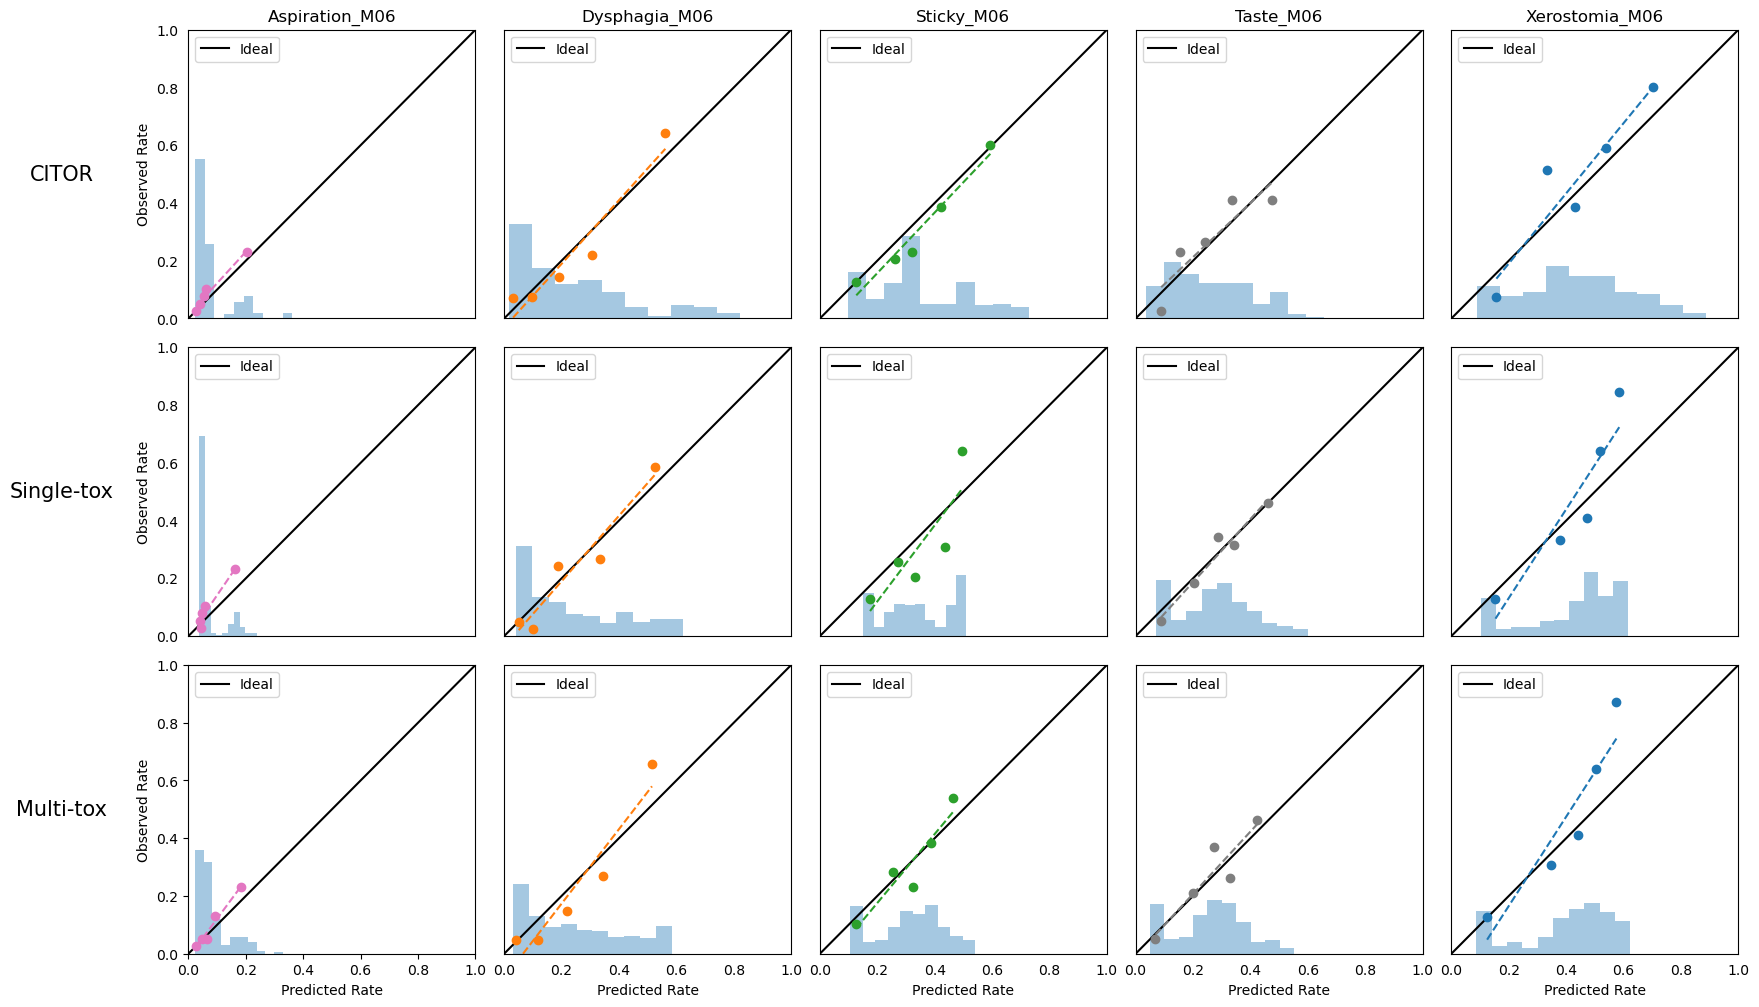

In [79]:
from src.visualization.calibration.calibration_plots import adaptive_make_calibration_plots


row_dicts = [CITOR_dict, ST_dict, MT_dict]
column_names = endpoints_list

config['evaluation']['metrics']['calibration_bins'] = 5

fig = adaptive_make_calibration_plots(config, row_dicts, column_names, title=None, mode='calibration', n_bins=5, filedir=None, return_fig=True)

plt.tight_layout()
plt.show()

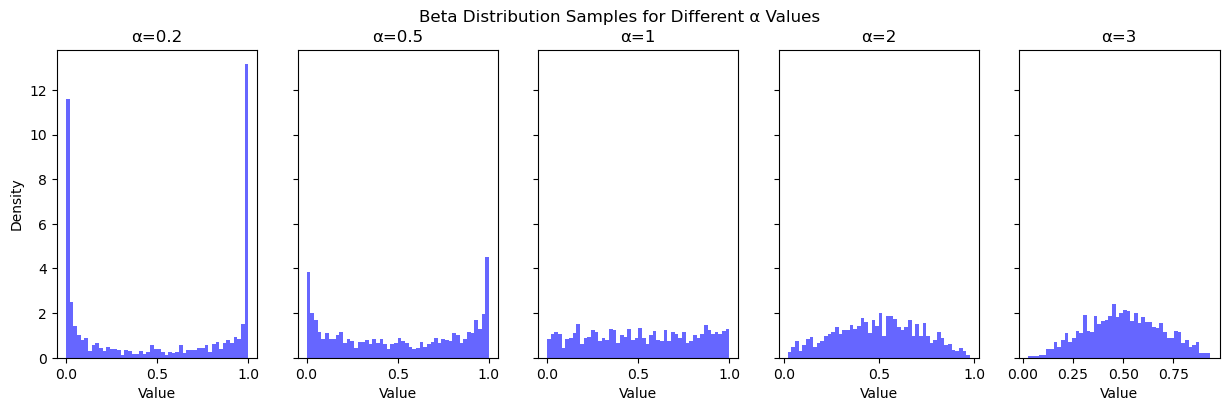

In [77]:
sample_size = 1000

alpha_values = [0.2, 0.5, 1, 2, 3]  # Different alpha values to test
beta_value = 1  # Keeping beta constant

fig, axes = plt.subplots(1, len(alpha_values), figsize=(15, 4), sharey=True)

for i, alpha in enumerate(alpha_values):
    samples = np.random.beta(alpha, alpha, sample_size)
    axes[i].hist(samples, bins=50, density=True, alpha=0.6, color='b')
    axes[i].set_title(f'α={alpha}')
    axes[i].set_xlabel('Value')
    
axes[0].set_ylabel('Density')
plt.suptitle('Beta Distribution Samples for Different α Values')
plt.show()